# Análisis de calidad y exploración del dataset

Este notebook analiza la calidad del dataset de abandono de clientes,
incluyendo estructura, tipos de variables, valores nulos, duplicados,
consistencia y distribución de la variable objetivo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
ruta = "../data/raw/customer_churn.csv"

df = pd.read_csv(
    ruta,
    keep_default_na=False,
    na_values=[""]
)

print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (10000, 32)


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


## 1. Estructura general del dataset

In [ ]:
df.columns.tolist()

['customer_id',
 'gender',
 'age',
 'country',
 'city',
 'customer_segment',
 'tenure_months',
 'signup_channel',
 'contract_type',
 'monthly_logins',
 'weekly_active_days',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'monthly_fee',
 'total_revenue',
 'payment_method',
 'payment_failures',
 'discount_applied',
 'price_increase_last_3m',
 'support_tickets',
 'avg_resolution_time',
 'complaint_type',
 'csat_score',
 'escalations',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score',
 'survey_response',
 'referral_count',
 'churn']

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  str    
 1   gender                  10000 non-null  str    
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  str    
 4   city                    10000 non-null  str    
 5   customer_segment        10000 non-null  str    
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  str    
 8   contract_type           10000 non-null  str    
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null  int64  
 1

## 2. Evaluación de la calidad de los datos

In [ ]:
calidad = pd.DataFrame({
    "tipo_dato": df.dtypes.astype(str),
    "cantidad_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

calidad

,tipo_dato,cantidad_nulos,porcentaje_nulos,valores_unicos
customer_id,str,0,0.0,10000
gender,str,0,0.0,2
age,int64,0,0.0,57
country,str,0,0.0,7
city,str,0,0.0,7
customer_segment,str,0,0.0,3
tenure_months,int64,0,0.0,59
signup_channel,str,0,0.0,3
contract_type,str,0,0.0,3
monthly_logins,int64,0,0.0,53


In [ ]:
total_nulos = df.isnull().sum().sum()
porcentaje_completitud = 100 - (total_nulos / df.size * 100)

print("Total de valores nulos:", total_nulos)
print(f"Completitud del dataset: {porcentaje_completitud:.2f}%")

Total de valores nulos: 0
Completitud del dataset: 100.00%


### Interpretación de la completitud

Luego de corregir la forma en que Pandas interpreta la categoría textual
`None`, no se detectaron valores nulos reales en el dataset.

Las 10.000 observaciones y 32 variables presentan datos completos, por lo
que la completitud global del dataset alcanza el 100 %.

In [ ]:
nulos_por_columna = pd.DataFrame({
    "cantidad_nulos": df.isnull().sum(),
    "porcentaje_nulos": (df.isnull().mean() * 100).round(2)
})

nulos_por_columna = (
    nulos_por_columna[nulos_por_columna["cantidad_nulos"] > 0]
    .sort_values("cantidad_nulos", ascending=False)
)

nulos_por_columna

,cantidad_nulos,porcentaje_nulos


### Interpretación de la categoría `None`

Durante la carga inicial del dataset, Pandas interpretó automáticamente
2.045 registros de la variable `complaint_type` como valores nulos (`NaN`).

Sin embargo, al revisar directamente el archivo original se comprobó que
estos registros contenían la categoría textual `None`, utilizada para
representar la ausencia de un tipo de reclamo. Por lo tanto, no corresponden
a datos faltantes reales.

Para conservar correctamente esta información, el dataset se recargó
desactivando la interpretación automática de valores nulos. Posteriormente,
la categoría `None` será renombrada como `No complaint` para facilitar su
comprensión.

In [ ]:
cantidad_duplicados = df.duplicated().sum()

print("Registros duplicados:", cantidad_duplicados)

Registros duplicados: 0


In [ ]:
duplicados_id = df["customer_id"].duplicated().sum()

print("Customer ID duplicados:", duplicados_id)

Customer ID duplicados: 0


### Interpretación de duplicados

No se detectaron filas completamente duplicadas ni identificadores
de clientes repetidos. Por lo tanto, cada registro corresponde a un
cliente distinto y no es necesario eliminar observaciones duplicadas.

## 4. Análisis de la variable `complaint_type`

In [ ]:
df["complaint_type"].value_counts(dropna=False)


complaint_type
Technical    3498
Billing      2427
None         2045
Service      2030
Name: count, dtype: int64

### 4.1 Normalización de la categoría `None`

La categoría textual `None` se renombra como `No complaint` para expresar
con mayor claridad que el cliente no presenta un tipo de reclamo registrado.
Esta modificación no corresponde a una imputación, ya que el valor estaba
presente en el archivo original.


In [ ]:
df_limpio = df.copy()

df_limpio["complaint_type"] = (
    df_limpio["complaint_type"]
    .replace("None", "No complaint")
)

df_limpio["complaint_type"].value_counts(dropna=False)

complaint_type
Technical       3498
Billing         2427
No complaint    2045
Service         2030
Name: count, dtype: int64

In [ ]:
print(
    "Total de valores nulos en el dataset limpio:",
    df_limpio.isnull().sum().sum()
)

print(
    "Categorías de complaint_type:",
    df_limpio["complaint_type"].unique()
)

Total de valores nulos en el dataset limpio: 0
Categorías de complaint_type: <StringArray>
['Service', 'Billing', 'Technical', 'No complaint']
Length: 4, dtype: str


In [ ]:
df_limpio.to_csv(
    "../data/processed/customer_churn_clean.csv",
    index=False
)

print("Dataset limpio guardado correctamente.")

Dataset limpio guardado correctamente.


## 5. Revisión de consistencia de los datos

In [ ]:
columnas_categoricas = df_limpio.select_dtypes(
    include=["object", "string"]
).columns

resumen_categorias = []

for columna in columnas_categoricas:
    categorias = sorted(
        df_limpio[columna]
        .astype(str)
        .unique()
        .tolist()
    )

    resumen_categorias.append({
        "variable": columna,
        "cantidad_categorias": len(categorias),
        "categorias": categorias
    })

resumen_categorias = pd.DataFrame(resumen_categorias)

resumen_categorias

,variable,cantidad_categorias,categorias
0,customer_id,10000,"[CUST_00001, CUST_00002, CUST_00003, CUST_0000..."
1,gender,2,"[Female, Male]"
2,country,7,"[Australia, Bangladesh, Canada, Germany, India..."
3,city,7,"[Berlin, Delhi, Dhaka, London, New York, Sydne..."
4,customer_segment,3,"[Enterprise, Individual, SME]"
5,signup_channel,3,"[Mobile, Referral, Web]"
6,contract_type,3,"[Monthly, Quarterly, Yearly]"
7,payment_method,3,"[Bank Transfer, Card, PayPal]"
8,discount_applied,2,"[No, Yes]"
9,price_increase_last_3m,2,"[No, Yes]"


In [ ]:
problemas_espacios = {}

for columna in columnas_categoricas:
    cantidad = (
        df_limpio[columna].astype(str)
        != df_limpio[columna].astype(str).str.strip()
    ).sum()

    if cantidad > 0:
        problemas_espacios[columna] = cantidad

problemas_espacios

{}

### 5.1 Revisión de rangos numéricos

In [ ]:
columnas_numericas = df_limpio.select_dtypes(
    include=["int64", "float64"]
).columns

resumen_numerico = (
    df_limpio[columnas_numericas]
    .describe()
    .T[["min", "max", "mean", "50%"]]
    .rename(columns={
        "min": "mínimo",
        "max": "máximo",
        "mean": "promedio",
        "50%": "mediana"
    })
)

resumen_numerico

,mínimo,máximo,promedio,mediana
age,18.00,74.000000,45.906100,46.000000
tenure_months,1.00,59.000000,30.155700,30.000000
monthly_logins,0.00,54.000000,19.672000,20.000000
weekly_active_days,0.00,7.000000,3.479400,3.000000
avg_session_time,1.00,41.996411,15.187890,15.161659
features_used,1.00,15.000000,4.990800,5.000000
usage_growth_rate,-0.58,0.540000,0.019423,0.020000
last_login_days_ago,0.00,80.000000,9.505200,6.000000
monthly_fee,10.00,100.000000,34.930000,30.000000
total_revenue,10.00,5900.000000,1057.018000,720.000000


In [ ]:
validaciones = {
    "Edad negativa": (df_limpio["age"] < 0).sum(),

    "Antigüedad negativa":
        (df_limpio["tenure_months"] < 0).sum(),

    "Días activos fuera de 0 a 7":
        (~df_limpio["weekly_active_days"].between(0, 7)).sum(),

    "Logins mensuales negativos":
        (df_limpio["monthly_logins"] < 0).sum(),

    "Tiempo de sesión negativo":
        (df_limpio["avg_session_time"] < 0).sum(),

    "Días desde último acceso negativos":
        (df_limpio["last_login_days_ago"] < 0).sum(),

    "Mensualidad negativa":
        (df_limpio["monthly_fee"] < 0).sum(),

    "Ingresos negativos":
        (df_limpio["total_revenue"] < 0).sum(),

    "Fallos de pago negativos":
        (df_limpio["payment_failures"] < 0).sum(),

    "Tickets negativos":
        (df_limpio["support_tickets"] < 0).sum(),

    "Churn distinto de 0 o 1":
        (~df_limpio["churn"].isin([0, 1])).sum()
}

pd.Series(validaciones, name="cantidad_inconsistencias")

Edad negativa                         0
Antigüedad negativa                   0
Días activos fuera de 0 a 7           0
Logins mensuales negativos            0
Tiempo de sesión negativo             0
Días desde último acceso negativos    0
Mensualidad negativa                  0
Ingresos negativos                    0
Fallos de pago negativos              0
Tickets negativos                     0
Churn distinto de 0 o 1               0
Name: cantidad_inconsistencias, dtype: int64

In [ ]:
columnas_binarias_texto = [
    "discount_applied",
    "price_increase_last_3m"
]

for columna in columnas_binarias_texto:
    print(f"{columna}:")
    print(df_limpio[columna].value_counts(dropna=False))
    print()

discount_applied:
discount_applied
No     6950
Yes    3050
Name: count, dtype: int64

price_increase_last_3m:
price_increase_last_3m
No     8055
Yes    1945
Name: count, dtype: int64



### Interpretación de la consistencia

La revisión de las variables categóricas binarias mostró que
`discount_applied` y `price_increase_last_3m` contienen únicamente las
categorías `Yes` y `No`, sin diferencias de escritura ni valores
inesperados.

Asimismo, las validaciones de rangos numéricos no identificaron valores
negativos o fuera de los límites lógicos establecidos. La variable objetivo
`churn` contiene exclusivamente los valores 0 y 1.

Por lo tanto, no fue necesario aplicar medidas correctivas adicionales por
problemas de consistencia.

## 6. Detección de valores atípicos

### 6.1 Identificación de valores atípicos

Se utiliza el método del rango intercuartílico (IQR) para identificar
observaciones numéricas alejadas de la distribución central de los datos.

Los valores detectados no serán eliminados automáticamente, ya que un valor
extremo puede representar una observación válida. Cada caso deberá analizarse
considerando el significado y el rango lógico de la variable.

In [ ]:
columnas_outliers = [
    columna
    for columna in df_limpio.select_dtypes(include=np.number).columns
    if columna != "churn"
    and df_limpio[columna].nunique() > 10
]

columnas_outliers

['age',
 'tenure_months',
 'monthly_logins',
 'avg_session_time',
 'features_used',
 'usage_growth_rate',
 'last_login_days_ago',
 'total_revenue',
 'avg_resolution_time',
 'email_open_rate',
 'marketing_click_rate',
 'nps_score']

In [ ]:
resultados_outliers = []

for columna in columnas_outliers:
    q1 = df_limpio[columna].quantile(0.25)
    q3 = df_limpio[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara_outliers = (
        (df_limpio[columna] < limite_inferior) |
        (df_limpio[columna] > limite_superior)
    )

    cantidad_outliers = mascara_outliers.sum()
    porcentaje_outliers = cantidad_outliers / len(df_limpio) * 100

    resultados_outliers.append({
        "variable": columna,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "limite_inferior": round(limite_inferior, 2),
        "limite_superior": round(limite_superior, 2),
        "cantidad_outliers": cantidad_outliers,
        "porcentaje_outliers": round(porcentaje_outliers, 2)
    })

resumen_outliers = (
    pd.DataFrame(resultados_outliers)
    .sort_values("cantidad_outliers", ascending=False)
)

resumen_outliers

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
7,total_revenue,340.00,1440.00,1100.00,-1310.00,3090.00,513,5.13
6,last_login_days_ago,2.00,13.00,11.00,-14.50,29.50,471,4.71
4,features_used,3.00,6.00,3.00,-1.50,10.50,121,1.21
5,usage_growth_rate,-0.08,0.12,0.20,-0.38,0.42,78,0.78
2,monthly_logins,13.00,26.00,13.00,-6.50,45.50,49,0.49
8,avg_resolution_time,17.08,30.76,13.68,-3.43,51.27,38,0.38
11,nps_score,-7.00,46.00,53.00,-86.50,125.50,36,0.36
3,avg_session_time,10.39,19.88,9.49,-3.84,34.12,27,0.27
0,age,32.00,60.00,28.00,-10.00,102.00,0,0.00
1,tenure_months,16.00,45.00,29.00,-27.50,88.50,0,0.00


In [ ]:
variables_con_outliers = resumen_outliers[
    resumen_outliers["cantidad_outliers"] > 0
]

variables_con_outliers

,variable,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
7,total_revenue,340.00,1440.00,1100.00,-1310.00,3090.00,513,5.13
6,last_login_days_ago,2.00,13.00,11.00,-14.50,29.50,471,4.71
4,features_used,3.00,6.00,3.00,-1.50,10.50,121,1.21
5,usage_growth_rate,-0.08,0.12,0.20,-0.38,0.42,78,0.78
2,monthly_logins,13.00,26.00,13.00,-6.50,45.50,49,0.49
8,avg_resolution_time,17.08,30.76,13.68,-3.43,51.27,38,0.38
11,nps_score,-7.00,46.00,53.00,-86.50,125.50,36,0.36
3,avg_session_time,10.39,19.88,9.49,-3.84,34.12,27,0.27


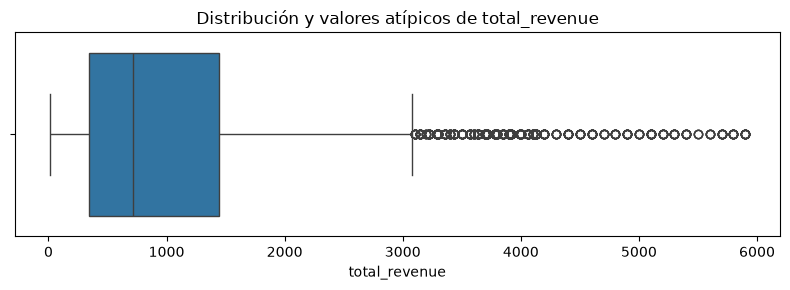

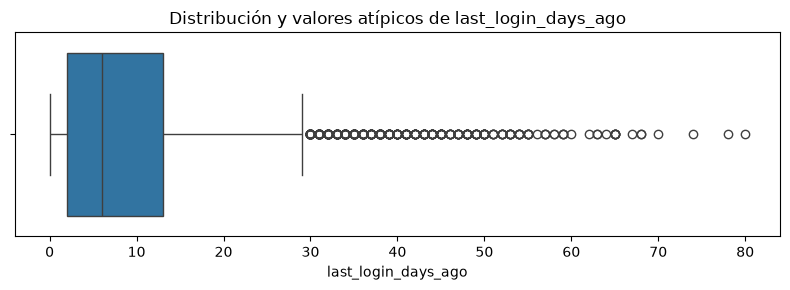

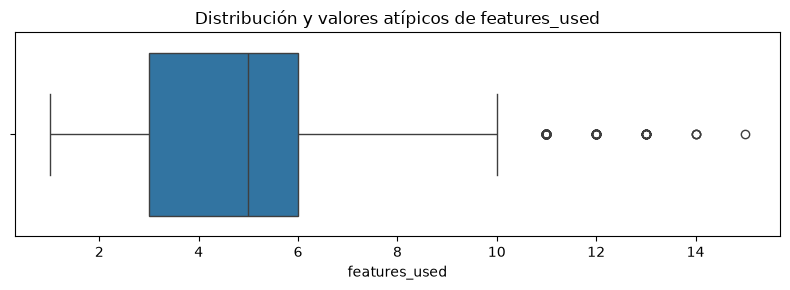

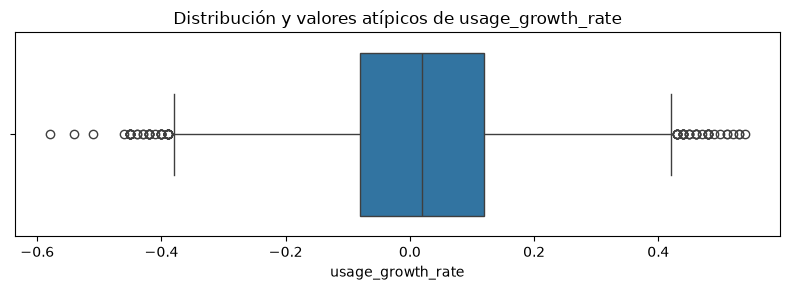

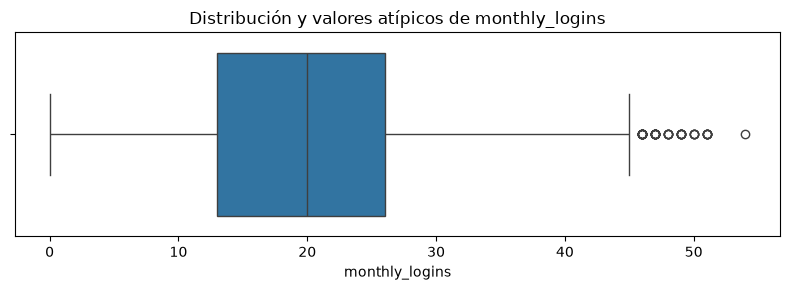

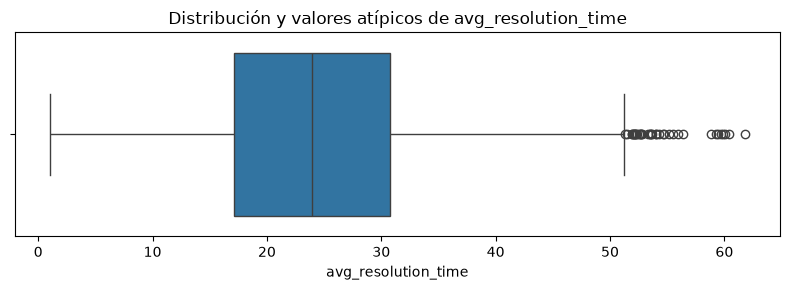

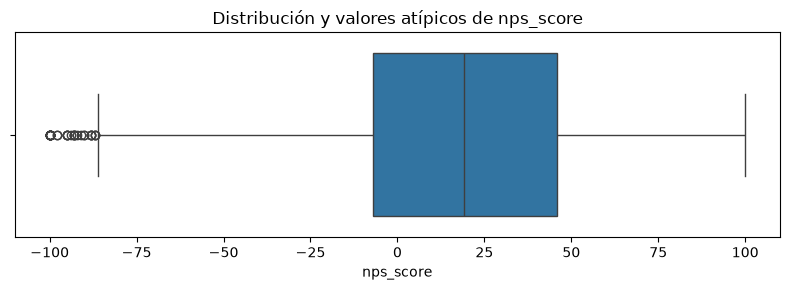

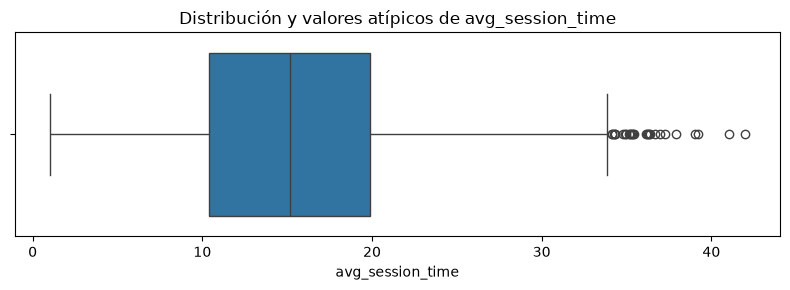

In [ ]:
columnas_con_outliers = variables_con_outliers["variable"].tolist()

for columna in columnas_con_outliers:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df_limpio,
        x=columna
    )

    plt.title(f"Distribución y valores atípicos de {columna}")
    plt.xlabel(columna)
    plt.tight_layout()
    plt.show()

In [ ]:
resumen_extremos = []

for columna in columnas_con_outliers:
    q1 = df_limpio[columna].quantile(0.25)
    q3 = df_limpio[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    mascara = (
        (df_limpio[columna] < limite_inferior) |
        (df_limpio[columna] > limite_superior)
    )

    resumen_extremos.append({
        "variable": columna,
        "mínimo_real": df_limpio[columna].min(),
        "máximo_real": df_limpio[columna].max(),
        "límite_inferior_IQR": round(limite_inferior, 2),
        "límite_superior_IQR": round(limite_superior, 2),
        "cantidad_atípicos": int(mascara.sum()),
        "porcentaje_atípicos": round(mascara.mean() * 100, 2)
    })

resumen_extremos = pd.DataFrame(resumen_extremos)

resumen_extremos

,variable,mínimo_real,máximo_real,límite_inferior_IQR,límite_superior_IQR,cantidad_atípicos,porcentaje_atípicos
0,total_revenue,10.00,5900.000000,-1310.00,3090.00,513,5.13
1,last_login_days_ago,0.00,80.000000,-14.50,29.50,471,4.71
2,features_used,1.00,15.000000,-1.50,10.50,121,1.21
3,usage_growth_rate,-0.58,0.540000,-0.38,0.42,78,0.78
4,monthly_logins,0.00,54.000000,-6.50,45.50,49,0.49
5,avg_resolution_time,1.00,61.821878,-3.43,51.27,38,0.38
6,nps_score,-100.00,100.000000,-86.50,125.50,36,0.36
7,avg_session_time,1.00,41.996411,-3.84,34.12,27,0.27


In [ ]:
validacion_extremos = {
    "Features usadas fuera de 1 a 15":
        (~df_limpio["features_used"].between(1, 15)).sum(),

    "NPS fuera de -100 a 100":
        (~df_limpio["nps_score"].between(-100, 100)).sum(),

    "Crecimiento de uso fuera de -1 a 1":
        (~df_limpio["usage_growth_rate"].between(-1, 1)).sum(),

    "Días desde último login negativos":
        (df_limpio["last_login_days_ago"] < 0).sum(),

    "Logins mensuales negativos":
        (df_limpio["monthly_logins"] < 0).sum(),

    "Tiempo de resolución negativo":
        (df_limpio["avg_resolution_time"] < 0).sum(),

    "Tiempo de sesión negativo":
        (df_limpio["avg_session_time"] < 0).sum(),

    "Ingresos totales negativos":
        (df_limpio["total_revenue"] < 0).sum()
}

pd.Series(
    validacion_extremos,
    name="cantidad_fuera_de_rango"
)

Features usadas fuera de 1 a 15       0
NPS fuera de -100 a 100               0
Crecimiento de uso fuera de -1 a 1    0
Días desde último login negativos     0
Logins mensuales negativos            0
Tiempo de resolución negativo         0
Tiempo de sesión negativo             0
Ingresos totales negativos            0
Name: cantidad_fuera_de_rango, dtype: int64

In [ ]:
ingreso_esperado = (
    df_limpio["tenure_months"] *
    df_limpio["monthly_fee"]
)

coincidencias_ingreso = (
    df_limpio["total_revenue"] == ingreso_esperado
).mean() * 100

print(
    f"Registros donde total_revenue coincide con "
    f"tenure_months × monthly_fee: {coincidencias_ingreso:.2f}%"
)

Registros donde total_revenue coincide con tenure_months × monthly_fee: 100.00%


### Interpretación de los valores atípicos

El método del rango intercuartílico identificó observaciones atípicas en
ocho variables numéricas. Las mayores proporciones se encontraron en
`total_revenue`, con 513 casos (5,13 %), y `last_login_days_ago`, con
471 casos (4,71 %).

La revisión de los valores mínimos, máximos y rangos lógicos indica que las
observaciones detectadas son plausibles dentro del contexto del problema.
Por ejemplo, los ingresos acumulados elevados pueden corresponder a clientes
con mayor antigüedad y mensualidad, mientras que los períodos prolongados
sin iniciar sesión pueden constituir señales relevantes de abandono.

Asimismo, variables como `nps_score`, `features_used` y
`usage_growth_rate` se mantienen dentro de sus escalas válidas. En
consecuencia, los valores atípicos serán conservados, ya que no existen
evidencias de errores de registro y su eliminación podría provocar pérdida
de información predictiva relevante.

## 7. Análisis exploratorio de datos

## 7. Análisis exploratorio de datos

En esta sección se analiza la distribución de las variables y su relación
con el abandono de clientes. El objetivo es identificar tendencias,
diferencias y patrones estadísticos que puedan resultar relevantes para la
posterior construcción de modelos de aprendizaje automático.

El análisis considera la variable objetivo `churn`, variables numéricas,
variables categóricas, distribuciones, tamaños del efecto, correlaciones y
relaciones conjuntas entre características.

In [ ]:
from pathlib import Path

Path("../figures").mkdir(
    parents=True,
    exist_ok=True
)

### 7.1 Distribución de la variable objetivo `churn`

La variable objetivo se encuentra codificada de forma binaria:

- `0`: el cliente permanece.
- `1`: el cliente abandona.

Se analiza su distribución para determinar si existe un desbalance entre
las clases.

In [ ]:
conteo_churn = (
    df_limpio["churn"]
    .value_counts()
    .sort_index()
)

porcentaje_churn = (
    df_limpio["churn"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

resumen_churn = pd.DataFrame({
    "cantidad": conteo_churn,
    "porcentaje": porcentaje_churn
})

resumen_churn = resumen_churn.rename(
    index={
        0: "Permanece (0)",
        1: "Abandona (1)"
    }
)

resumen_churn

,cantidad,porcentaje
churn,,
Permanece (0),8979,89.79
Abandona (1),1021,10.21


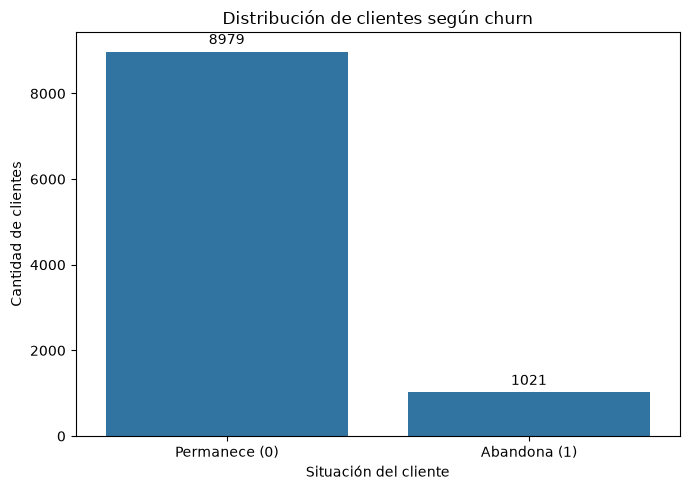

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_limpio,
    x="churn"
)

plt.title("Distribución de clientes según churn")
plt.xlabel("Situación del cliente")
plt.ylabel("Cantidad de clientes")

plt.xticks(
    ticks=[0, 1],
    labels=[
        "Permanece (0)",
        "Abandona (1)"
    ]
)

for contenedor in ax.containers:
    ax.bar_label(
        contenedor,
        fmt="%d",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../figures/07_distribucion_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
cantidad_mayoritaria = conteo_churn.max()
cantidad_minoritaria = conteo_churn.min()

relacion_clases = (
    cantidad_mayoritaria /
    cantidad_minoritaria
)

print(
    "Cantidad de la clase mayoritaria:",
    cantidad_mayoritaria
)

print(
    "Cantidad de la clase minoritaria:",
    cantidad_minoritaria
)

print(
    f"Relación entre clase mayoritaria y minoritaria: "
    f"{relacion_clases:.2f} a 1"
)

print(
    "Valores presentes en churn:",
    sorted(
        df_limpio["churn"]
        .astype(int)
        .unique()
        .tolist()
    )
)

Cantidad de la clase mayoritaria: 8979
Cantidad de la clase minoritaria: 1021
Relación entre clase mayoritaria y minoritaria: 8.79 a 1
Valores presentes en churn: [0, 1]


### Interpretación de la variable objetivo

La variable objetivo `churn` contiene exclusivamente las clases 0 y 1.

De los 10.000 clientes analizados, 8.979 permanecen, equivalentes al
89,79 %, mientras que 1.021 abandonan el servicio, representando el
10,21 %.

La relación entre la clase mayoritaria y la minoritaria es de 8,79 a 1,
lo que evidencia un desbalance importante.

Por esta razón, la exactitud (`accuracy`) no será suficiente para evaluar
los modelos. En etapas posteriores se utilizarán particiones estratificadas
y métricas como precision, recall, F1-score, AUC-ROC y matriz de confusión.
También se evaluarán estrategias de balanceo aplicadas exclusivamente al
conjunto de entrenamiento.

### 7.2 Comparación de variables numéricas según churn

Se comparan las medias y medianas de variables numéricas relevantes entre
los clientes que permanecen y aquellos que abandonan.

El objetivo es identificar características cuyo comportamiento sea diferente
entre ambos grupos.

In [ ]:
variables_relevantes = [
    "tenure_months",
    "monthly_logins",
    "weekly_active_days",
    "avg_session_time",
    "features_used",
    "usage_growth_rate",
    "last_login_days_ago",
    "monthly_fee",
    "total_revenue",
    "payment_failures",
    "support_tickets",
    "avg_resolution_time",
    "csat_score",
    "nps_score"
]

comparacion_churn = (
    df_limpio
    .groupby("churn")[variables_relevantes]
    .agg(["mean", "median"])
    .round(2)
    .T
)

comparacion_churn.columns = [
    "Permanece (0)",
    "Abandona (1)"
]

comparacion_churn

Permanece (0)  Abandona (1)
tenure_months       mean            30.83         24.22
                    median          31.00         22.00
monthly_logins      mean            20.00         16.80
                    median          20.00         17.00
weekly_active_days  mean             3.49          3.42
                    median           3.00          3.00
avg_session_time    mean            15.20         15.09
                    median          15.21         14.75
features_used       mean             4.99          5.03
                    median           5.00          5.00
usage_growth_rate   mean             0.02          0.02
                    median           0.02          0.02
last_login_days_ago mean             9.38         10.59
                    median           6.00          7.00
monthly_fee         mean            34.97         34.57
                    median          30.00         30.00
total_revenue       mean          1081.14        844.90
                    median         750.00        490.00
payment_failures    mean             0.47          0.74
                    median           0.00          0.00
support_tickets     mean             1.21          1.21
                    median           1.00          1.00
avg_resolution_time mean            23.98         23.68
                    median          24.03         23.47
csat_score          mean             3.54          3.03
                    median           4.00          3.00
nps_score           mean            19.07         19.46
                    median          19.00         18.00

### Interpretación inicial de las variables numéricas

La comparación muestra que las diferencias entre ambos grupos no son
extremas, aunque se identifican señales relevantes.

Los clientes que abandonan presentan, en promedio:

- Menor antigüedad.
- Menor cantidad de accesos mensuales.
- Más fallos de pago.
- Menor satisfacción.
- Menores ingresos acumulados.
- Más días desde su último acceso.

Sin embargo, la mayoría de las variables no permite distinguir claramente
a ambos grupos por sí sola. Esto sugiere que el abandono podría depender de
la combinación de múltiples factores.

### 7.3 Tamaño del efecto mediante Cohen's d

La diferencia entre dos promedios no permite determinar por sí sola si una
variable distingue de manera relevante a los grupos.

Por esta razón, se calcula el tamaño del efecto de Cohen, que expresa la
magnitud estandarizada de la diferencia entre quienes permanecen y quienes
abandonan.

In [ ]:
def cohens_d(grupo_0, grupo_1):
    grupo_0 = grupo_0.dropna()
    grupo_1 = grupo_1.dropna()

    varianza_combinada = (
        (
            (len(grupo_0) - 1) *
            grupo_0.var(ddof=1)
        )
        +
        (
            (len(grupo_1) - 1) *
            grupo_1.var(ddof=1)
        )
    ) / (
        len(grupo_0) +
        len(grupo_1) -
        2
    )

    desviacion_combinada = np.sqrt(
        varianza_combinada
    )

    if desviacion_combinada == 0:
        return np.nan

    return (
        grupo_1.mean() -
        grupo_0.mean()
    ) / desviacion_combinada


resultados_efecto = []

for columna in variables_relevantes:
    grupo_permanece = df_limpio.loc[
        df_limpio["churn"] == 0,
        columna
    ]

    grupo_abandona = df_limpio.loc[
        df_limpio["churn"] == 1,
        columna
    ]

    resultados_efecto.append({
        "variable": columna,
        "media_permanece":
            grupo_permanece.mean(),
        "media_abandona":
            grupo_abandona.mean(),
        "cohens_d": cohens_d(
            grupo_permanece,
            grupo_abandona
        )
    })

efectos = pd.DataFrame(
    resultados_efecto
)

efectos["efecto_absoluto"] = (
    efectos["cohens_d"].abs()
)

efectos = efectos.sort_values(
    "efecto_absoluto",
    ascending=False
).round(3)

efectos

,variable,media_permanece,media_abandona,cohens_d,efecto_absoluto
12,csat_score,3.539,3.028,-0.528,0.528
0,tenure_months,30.830,24.222,-0.389,0.389
9,payment_failures,0.474,0.738,0.374,0.374
1,monthly_logins,19.998,16.803,-0.326,0.326
8,total_revenue,1081.138,844.897,-0.232,0.232
6,last_login_days_ago,9.382,10.588,0.123,0.123
11,avg_resolution_time,23.984,23.682,-0.030,0.030
2,weekly_active_days,3.486,3.419,-0.029,0.029
4,features_used,4.987,5.026,0.018,0.018
5,usage_growth_rate,0.019,0.022,0.017,0.017


### Interpretación del tamaño del efecto

El análisis mediante Cohen's d muestra que la mayoría de las variables
numéricas presenta diferencias pequeñas o prácticamente nulas entre los
clientes que permanecen y aquellos que abandonan.

La variable con mayor capacidad de diferenciación individual es
`csat_score`, con un tamaño de efecto moderado cercano a 0,53. Los clientes
que abandonan presentan una satisfacción promedio inferior a quienes
permanecen.

También se identificaron diferencias pequeñas en:

- `tenure_months`.
- `payment_failures`.
- `monthly_logins`.
- `total_revenue`.

Los clientes que abandonan muestran menor antigüedad, más fallos de pago,
menos accesos mensuales y menores ingresos acumulados.

Las demás variables numéricas presentan tamaños de efecto muy pequeños.
Esto sugiere que el churn no depende de una única característica, sino de
la interacción entre múltiples factores.

### 7.4 Distribución de las variables numéricas más relevantes

Se utilizan boxplots para comparar la mediana, dispersión y distribución de
las variables numéricas con mayor tamaño del efecto entre ambos grupos de
clientes.

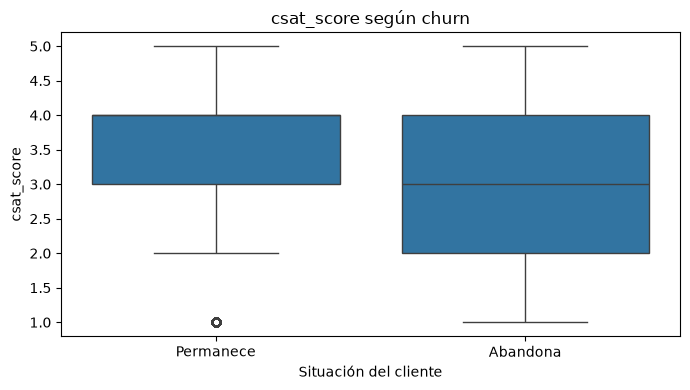

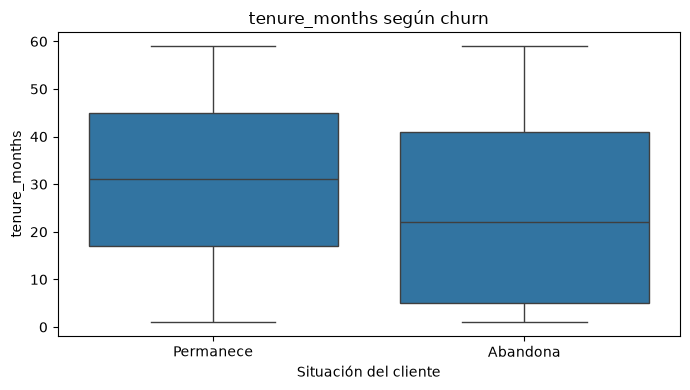

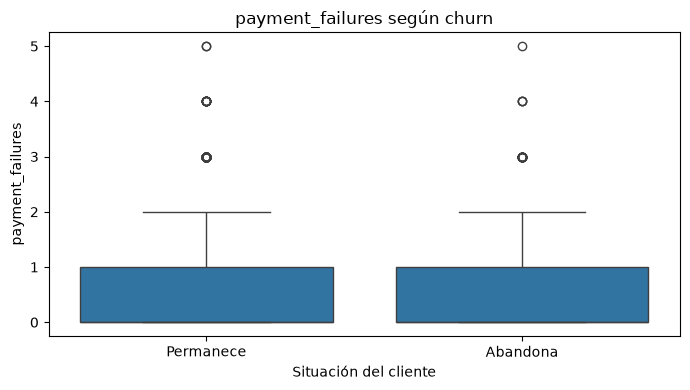

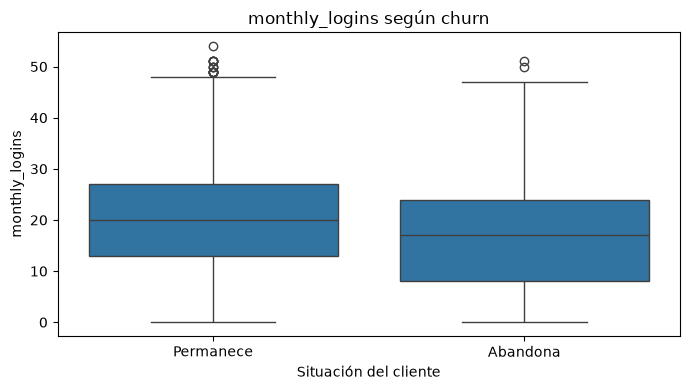

In [ ]:
variables_numericas_destacadas = [
    "csat_score",
    "tenure_months",
    "payment_failures",
    "monthly_logins"
]

for variable in variables_numericas_destacadas:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df_limpio,
        x="churn",
        y=variable
    )

    plt.title(
        f"{variable} según churn"
    )

    plt.xlabel("Situación del cliente")
    plt.ylabel(variable)

    plt.xticks(
        ticks=[0, 1],
        labels=[
            "Permanece",
            "Abandona"
        ]
    )

    plt.tight_layout()

    plt.savefig(
        f"../figures/07_04_{variable}_churn.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Interpretación de las distribuciones numéricas

Los boxplots confirman que `csat_score` presenta la diferencia más visible
entre ambos grupos. Los clientes que abandonan tienden a registrar niveles
de satisfacción inferiores.

También se observan diferencias en antigüedad, cantidad de fallos de pago y
frecuencia de accesos mensuales.

No obstante, existe una superposición considerable entre las distribuciones.
Por ello, ninguna de estas variables permite identificar individualmente a
todos los clientes que abandonarán.

### 7.5 Histogramas de variables numéricas relevantes

Los histogramas permiten observar la forma completa de la distribución de
las variables, en lugar de limitar el análisis a promedios, medianas o
cuartiles.

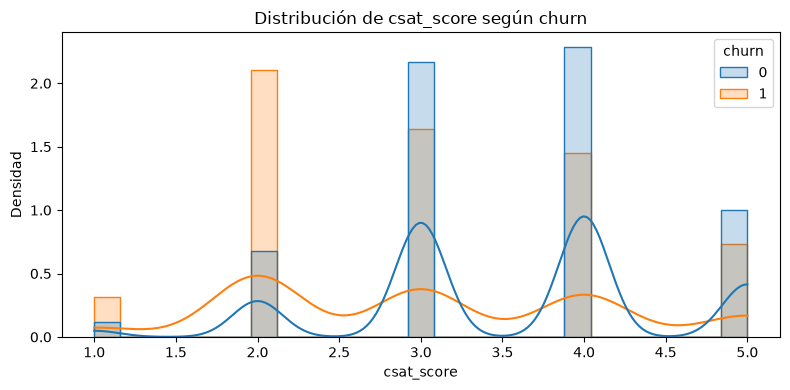

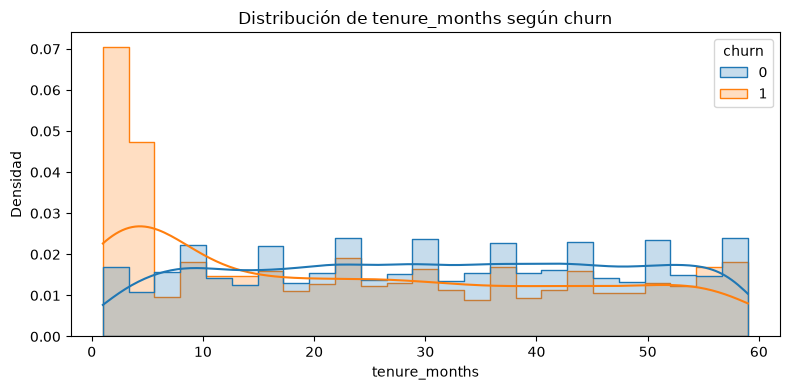

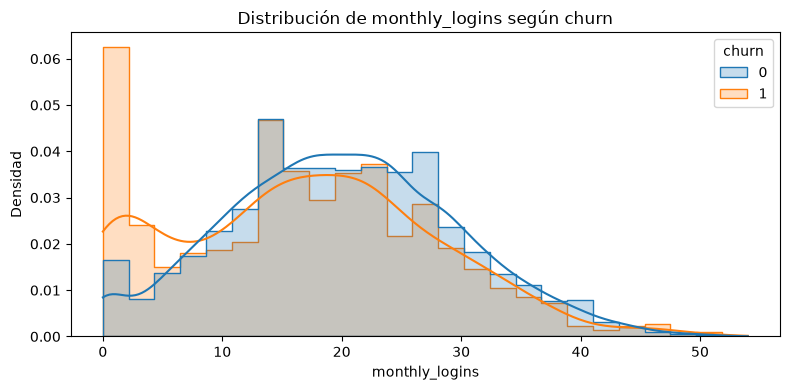

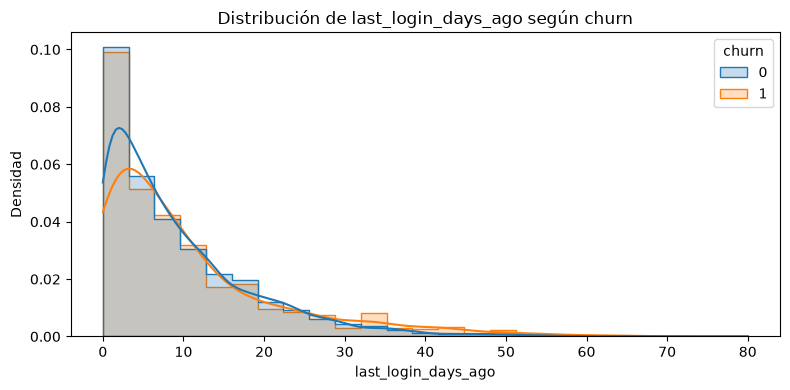

In [ ]:
variables_histogramas = [
    "csat_score",
    "tenure_months",
    "monthly_logins",
    "last_login_days_ago"
]

for variable in variables_histogramas:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df_limpio,
        x=variable,
        hue="churn",
        bins=25,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(
        f"Distribución de {variable} según churn"
    )

    plt.xlabel(variable)
    plt.ylabel("Densidad")

    plt.tight_layout()

    plt.savefig(
        f"../figures/07_05_histograma_{variable}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### Interpretación de los histogramas

Las distribuciones de clientes que permanecen y abandonan presentan una
superposición importante, lo que confirma que ninguna variable numérica
separa completamente a las dos clases.

Sin embargo, se observan desplazamientos en variables como satisfacción,
antigüedad y frecuencia de acceso. Estas diferencias pueden resultar útiles
cuando se combinan con otras características dentro de un modelo predictivo.

### 7.6 Relación entre variables categóricas y churn

Se calcula la tasa de abandono dentro de cada categoría para determinar si
existen tipos de contrato, segmentos, métodos de pago u otras características
asociadas con una mayor proporción de churn.

Como `churn` está codificado mediante 0 y 1, su promedio dentro de una
categoría equivale directamente a la tasa de abandono de esa categoría.

In [ ]:
variables_categoricas_relevantes = [
    "gender",
    "customer_segment",
    "signup_channel",
    "contract_type",
    "payment_method",
    "discount_applied",
    "price_increase_last_3m",
    "complaint_type",
    "survey_response"
]

resumen_brechas_categoricas = []

for columna in variables_categoricas_relevantes:
    tabla = (
        df_limpio
        .groupby(
            columna,
            observed=False
        )["churn"]
        .agg(["count", "mean"])
        .sort_values(
            "mean",
            ascending=False
        )
    )

    tabla["tasa_churn_pct"] = (
        tabla["mean"]
        .mul(100)
        .round(2)
    )

    print(f"\n--- {columna} ---")
    display(
        tabla[
            [
                "count",
                "tasa_churn_pct"
            ]
        ]
    )

    brecha = (
        tabla["tasa_churn_pct"].max()
        -
        tabla["tasa_churn_pct"].min()
    )

    resumen_brechas_categoricas.append({
        "variable": columna,
        "brecha_churn_puntos_pct":
            round(brecha, 2)
    })

brechas_categoricas = (
    pd.DataFrame(
        resumen_brechas_categoricas
    )
    .sort_values(
        "brecha_churn_puntos_pct",
        ascending=False
    )
)

brechas_categoricas


--- gender ---


,count,tasa_churn_pct
gender,,
Male,5013,10.31
Female,4987,10.11



--- customer_segment ---


,count,tasa_churn_pct
customer_segment,,
SME,3029,10.93
Individual,5984,9.98
Enterprise,987,9.42



--- signup_channel ---


...


--- complaint_type ---


,count,tasa_churn_pct
complaint_type,,
Technical,3498,10.32
No complaint,2045,10.32
Billing,2427,10.18
Service,2030,9.95



--- survey_response ---


,count,tasa_churn_pct
survey_response,,
Unsatisfied,2047,11.14
Satisfied,4975,10.13
Neutral,2978,9.70


,variable,brecha_churn_puntos_pct
1,customer_segment,1.51
8,survey_response,1.44
2,signup_channel,1.23
5,discount_applied,0.86
4,payment_method,0.51
3,contract_type,0.41
7,complaint_type,0.37
6,price_increase_last_3m,0.22
0,gender,0.20


In [ ]:
def graficar_tasa_churn(variable):
    tasa = (
        df_limpio
        .groupby(
            variable,
            observed=False
        )["churn"]
        .mean()
        .mul(100)
        .sort_values(
            ascending=False
        )
    )

    plt.figure(figsize=(8, 5))

    ax = sns.barplot(
        x=tasa.index,
        y=tasa.values
    )

    plt.title(
        f"Tasa de churn según {variable}"
    )

    plt.xlabel(variable)
    plt.ylabel("Tasa de churn (%)")

    plt.xticks(
        rotation=45,
        ha="right"
    )

    for contenedor in ax.containers:
        ax.bar_label(
            contenedor,
            fmt="%.1f%%",
            padding=3
        )

    plt.tight_layout()

    plt.savefig(
        f"../figures/07_06_churn_{variable}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

Variables categóricas con mayor brecha: ['customer_segment', 'survey_response', 'signup_channel', 'discount_applied']


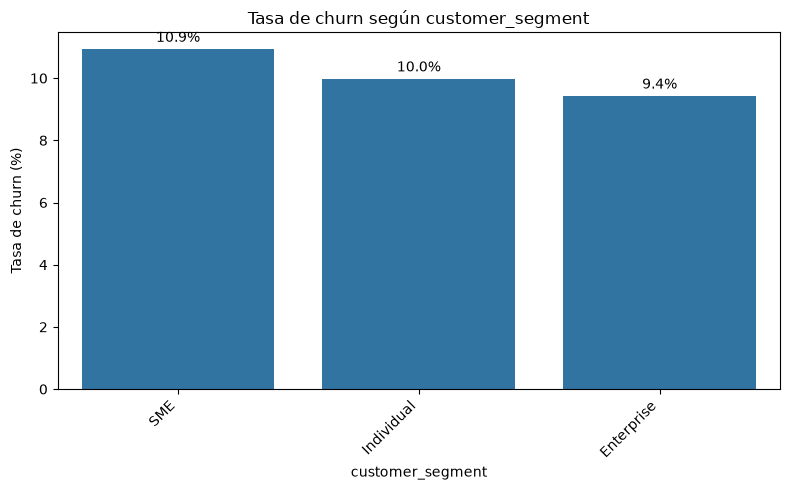

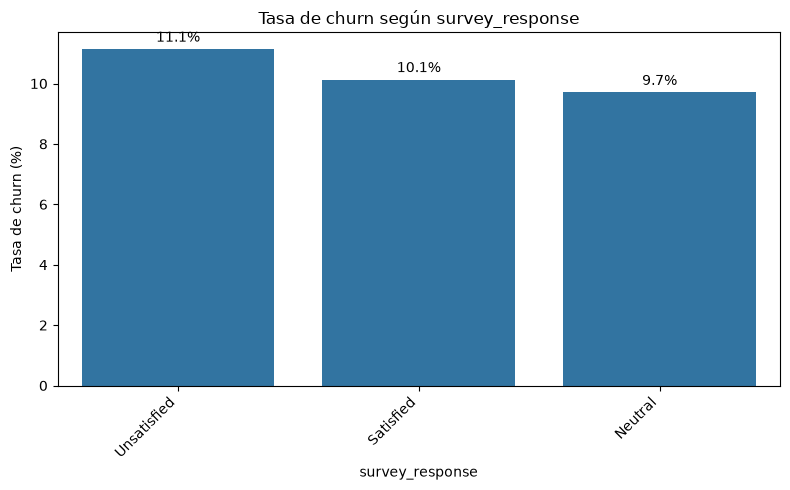

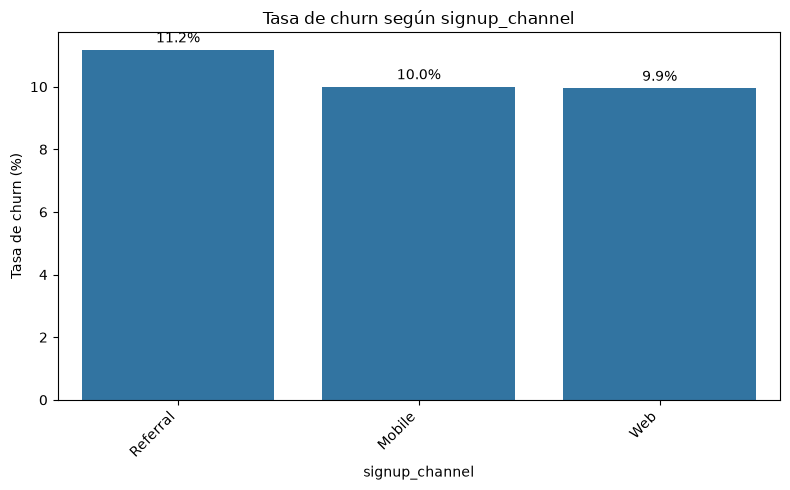

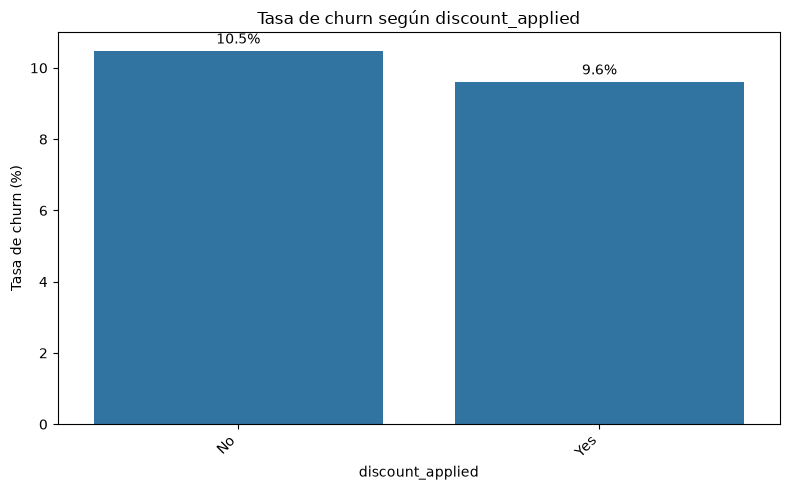

In [ ]:
top_categoricas = (
    brechas_categoricas
    .head(4)["variable"]
    .tolist()
)

print(
    "Variables categóricas con mayor brecha:",
    top_categoricas
)

for variable in top_categoricas:
    graficar_tasa_churn(
        variable
    )

### Interpretación de las variables categóricas

Las variables categóricas con mayores diferencias en sus tasas de churn
fueron `customer_segment`, `survey_response`, `signup_channel` y
`discount_applied`.

En `customer_segment`, los clientes SME presentaron la mayor tasa de churn,
con un 10,9 %, mientras que los clientes Enterprise registraron un 9,4 %.
La diferencia entre ambos segmentos fue de 1,5 puntos porcentuales.

En `survey_response`, los clientes insatisfechos mostraron la tasa más alta,
con un 11,1 %, frente al 9,7 % de los clientes con respuesta neutral. Sin
embargo, la diferencia fue de solo 1,4 puntos porcentuales y no se observó
una relación completamente ordenada entre satisfacción declarada y churn.

La variable `signup_channel` presentó tasas entre 9,9 % y 11,2 %, alcanzando
una brecha máxima aproximada de 1,3 puntos porcentuales.

Respecto de `discount_applied`, los clientes sin descuento registraron una
tasa de churn del 10,5 %, mientras que aquellos con descuento presentaron
un 9,6 %. La brecha fue de 0,9 puntos porcentuales.

Aunque estas fueron las variables categóricas con mayores diferencias, las
brechas observadas son pequeñas. Por lo tanto, ninguna categoría permite
explicar individualmente el abandono de los clientes.

Estos resultados respaldan la hipótesis de que el churn depende de la
combinación de múltiples variables numéricas y categóricas, más que de una
característica aislada.

### 7.7 Análisis de correlaciones

Se analiza la correlación entre las variables numéricas para identificar
relaciones lineales y posibles asociaciones con la variable objetivo
`churn`.

El coeficiente de correlación toma valores entre -1 y 1:

- Valores cercanos a 1 indican una relación positiva.
- Valores cercanos a -1 indican una relación negativa.
- Valores cercanos a 0 indican una relación lineal débil o inexistente.

La correlación permite detectar asociaciones entre variables, pero no
demuestra que una variable provoque cambios en otra.

In [ ]:
variables_correlacion = [
    "churn",
    "tenure_months",
    "monthly_logins",
    "weekly_active_days",
    "avg_session_time",
    "features_used",
    "usage_growth_rate",
    "last_login_days_ago",
    "monthly_fee",
    "total_revenue",
    "payment_failures",
    "support_tickets",
    "avg_resolution_time",
    "csat_score",
    "nps_score"
]

matriz_correlacion = (
    df_limpio[variables_correlacion]
    .corr()
)

matriz_correlacion.round(2)

,churn,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,nps_score
churn,1.00,-0.12,-0.10,-0.01,-0.00,0.01,0.01,0.04,-0.01,-0.07,0.11,0.00,-0.01,-0.16,0.00
tenure_months,-0.12,1.00,-0.01,0.00,0.04,-0.01,0.01,0.01,0.01,0.59,0.00,-0.01,-0.00,-0.01,0.01
monthly_logins,-0.10,-0.01,1.00,0.03,0.00,0.01,-0.01,0.01,-0.02,-0.02,0.01,-0.02,-0.01,-0.00,-0.00
weekly_active_days,-0.01,0.00,0.03,1.00,0.01,-0.00,-0.01,-0.01,-0.00,0.00,-0.01,0.01,0.01,0.01,-0.01
avg_session_time,-0.00,0.04,0.00,0.01,1.00,0.01,-0.01,0.00,0.00,0.02,-0.02,0.01,-0.00,-0.01,-0.00
features_used,0.01,-0.01,0.01,-0.00,0.01,1.00,0.02,0.00,-0.01,-0.01,0.01,-0.01,-0.01,-0.01,0.01
usage_growth_rate,0.01,0.01,-0.01,-0.01,-0.01,0.02,1.00,0.01,-0.01,0.00,-0.02,-0.00,0.01,-0.02,0.00
last_login_days_ago,0.04,0.01,0.01,-0.01,0.00,0.00,0.01,1.00,-0.01,0.00,0.02,-0.02,-0.00,-0.01,0.00
monthly_fee,-0.01,0.01,-0.02,-0.00,0.00,-0.01,-0.01,-0.01,1.00,0.71,0.01,0.00,0.01,0.01,-0.01
total_revenue,-0.07,0.59,-0.02,0.00,0.02,-0.01,0.00,0.00,0.71,1.00,0.01,0.00,0.01,0.00,0.01


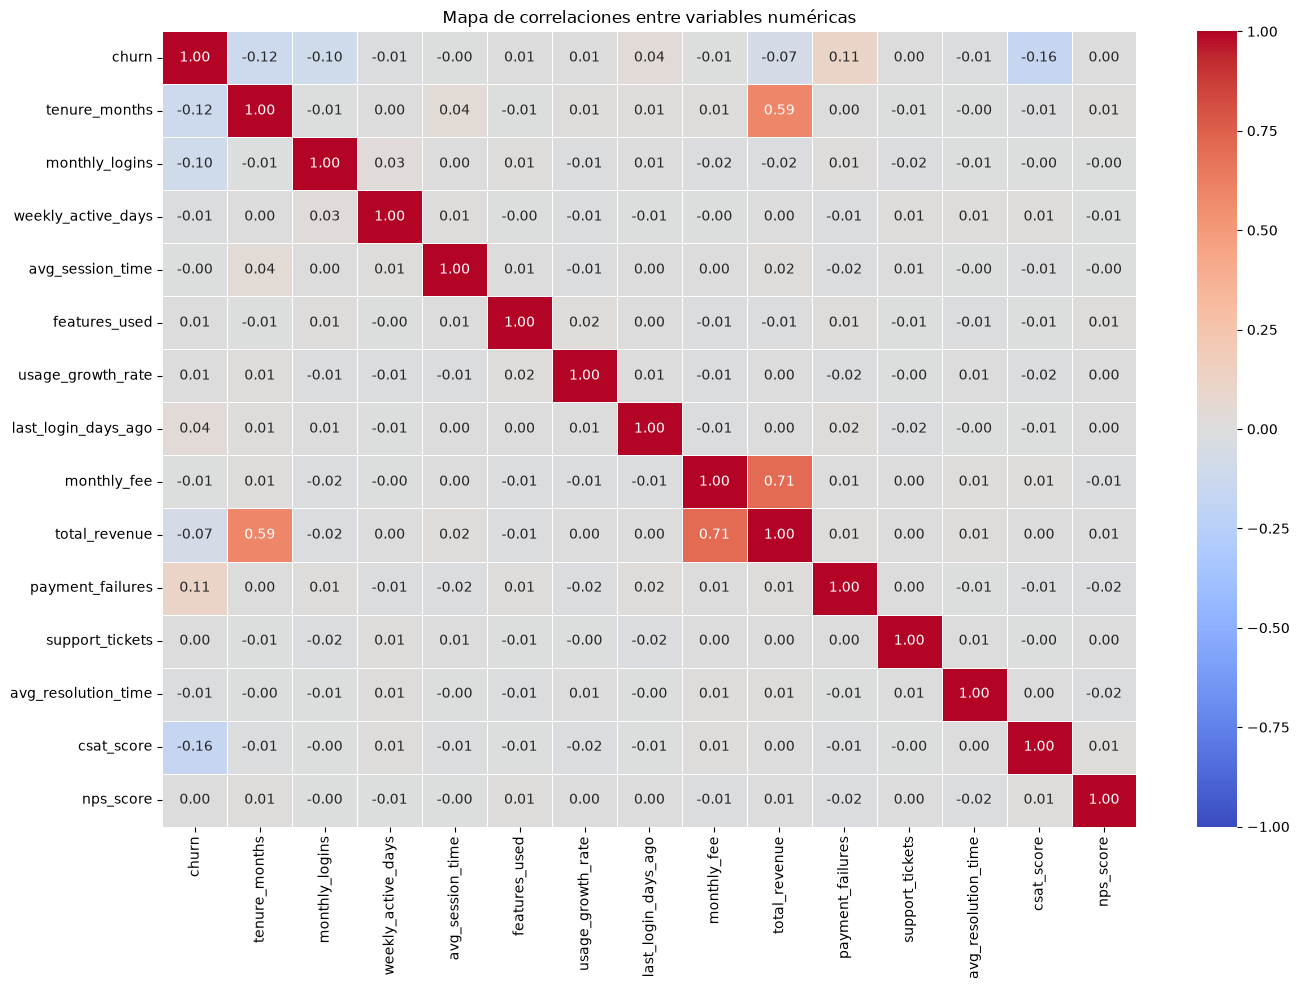

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Mapa de correlaciones entre variables numéricas"
)

plt.tight_layout()

plt.savefig(
    "../figures/07_07_mapa_correlaciones.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
correlacion_churn = (
    matriz_correlacion["churn"]
    .drop("churn")
    .sort_values(
        key=abs,
        ascending=False
    )
)

correlacion_churn.to_frame(
    name="correlacion_con_churn"
).round(3)

,correlacion_con_churn
csat_score,-0.158
tenure_months,-0.117
payment_failures,0.112
monthly_logins,-0.098
total_revenue,-0.070
last_login_days_ago,0.037
avg_resolution_time,-0.009
weekly_active_days,-0.009
features_used,0.005
usage_growth_rate,0.005


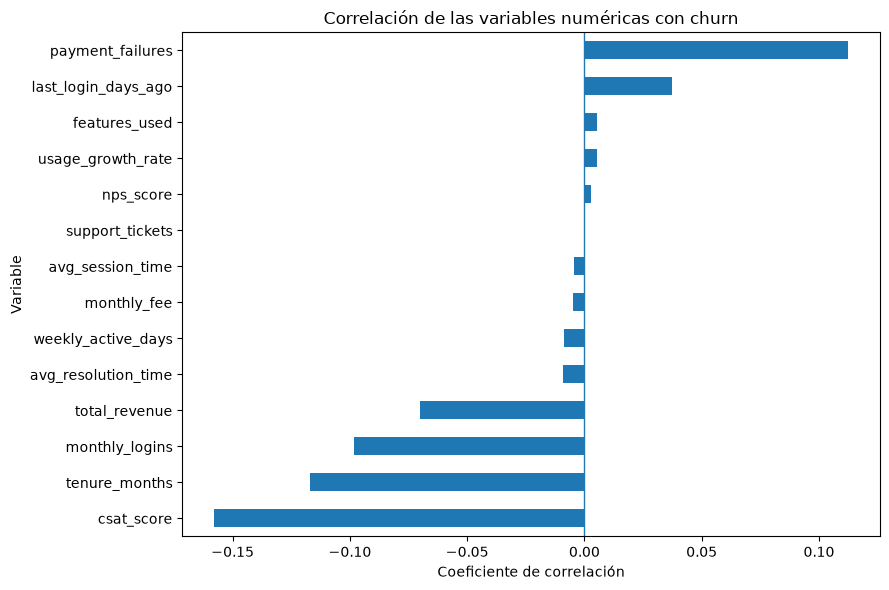

In [ ]:
plt.figure(figsize=(9, 6))

correlacion_churn.sort_values().plot(
    kind="barh"
)

plt.title(
    "Correlación de las variables numéricas con churn"
)

plt.xlabel(
    "Coeficiente de correlación"
)

plt.ylabel(
    "Variable"
)

plt.axvline(
    x=0,
    linewidth=1
)

plt.tight_layout()

plt.savefig(
    "../figures/07_07_correlacion_churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretación de las correlaciones

Las correlaciones entre las variables numéricas y `churn` son débiles.

La mayor asociación se observa en `csat_score`, con una correlación de
-0,158. Esto indica que mayores niveles de satisfacción tienden a estar
asociados con una menor tasa de abandono.

También se identificaron asociaciones negativas en `tenure_months`
(-0,117) y `monthly_logins` (-0,098). En términos generales, los clientes
con mayor antigüedad y mayor frecuencia de acceso tienden a presentar un
menor nivel de churn.

La variable `payment_failures` mostró una correlación positiva de 0,112,
lo que indica que una mayor cantidad de fallos de pago se relaciona con
una mayor probabilidad de abandono.

Las demás variables presentan correlaciones muy cercanas a cero, por lo
que su relación lineal individual con el churn es limitada.

Entre las variables explicativas, `total_revenue` mostró una correlación
de 0,71 con `monthly_fee` y de 0,59 con `tenure_months`. Esto sugiere que
los ingresos acumulados dependen, al menos parcialmente, de la tarifa
mensual y de la antigüedad del cliente.

En general, los resultados confirman que no existe una variable numérica
con una relación lineal dominante respecto del churn. Por lo tanto, será
necesario utilizar modelos que combinen múltiples variables y que puedan
detectar relaciones lineales y no lineales.

In [ ]:
ingreso_calculado = (
    df_limpio["tenure_months"] *
    df_limpio["monthly_fee"]
)

coincidencias_ingreso = np.isclose(
    df_limpio["total_revenue"],
    ingreso_calculado,
    atol=0.01
).mean() * 100

diferencia_promedio = (
    df_limpio["total_revenue"] -
    ingreso_calculado
).abs().mean()

print(
    f"Registros donde total_revenue coincide con "
    f"tenure_months × monthly_fee: "
    f"{coincidencias_ingreso:.2f}%"
)

print(
    f"Diferencia absoluta promedio: "
    f"{diferencia_promedio:.2f}"
)

Registros donde total_revenue coincide con tenure_months × monthly_fee: 100.00%
Diferencia absoluta promedio: 0.00


### 7.8 Relación conjunta entre accesos y satisfacción

Se analiza conjuntamente la cantidad de accesos mensuales y el nivel de
satisfacción del cliente mediante un gráfico de dispersión.

El objetivo es observar si la combinación de ambas variables permite
distinguir visualmente a los clientes que permanecen de aquellos que
abandonan.

Para evitar la saturación del gráfico, se utiliza una muestra aleatoria
reproducible de 3.000 registros.

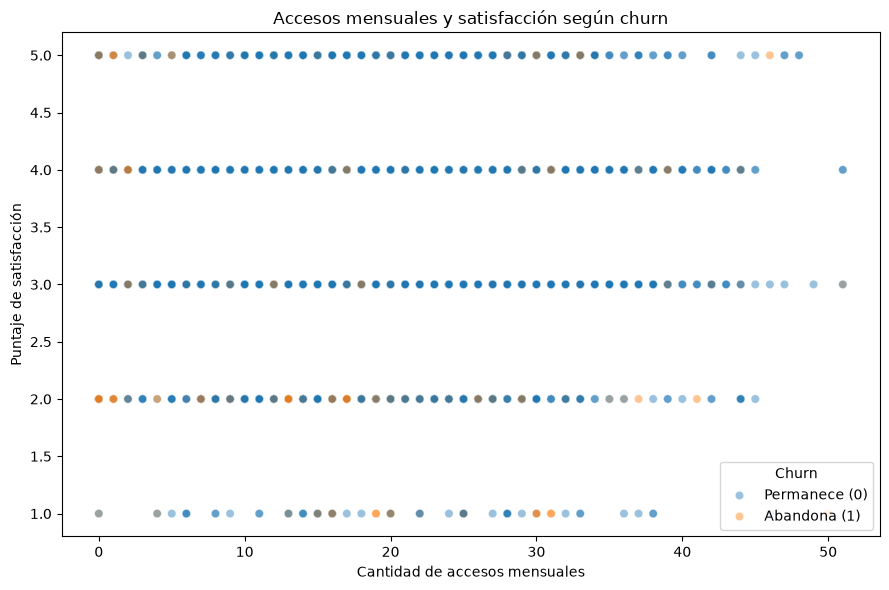

In [ ]:
muestra_dispersion = df_limpio.sample(
    n=min(3000, len(df_limpio)),
    random_state=42
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=muestra_dispersion,
    x="monthly_logins",
    y="csat_score",
    hue="churn",
    alpha=0.45
)

plt.title(
    "Accesos mensuales y satisfacción según churn"
)

plt.xlabel(
    "Cantidad de accesos mensuales"
)

plt.ylabel(
    "Puntaje de satisfacción"
)

handles, labels = plt.gca().get_legend_handles_labels()

plt.legend(
    handles=handles,
    labels=[
        "Permanece (0)",
        "Abandona (1)"
    ],
    title="Churn"
)

plt.tight_layout()

plt.savefig(
    "../figures/07_08_dispersion_logins_csat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretación del gráfico de dispersión

El gráfico muestra una superposición considerable entre los clientes que
permanecen y aquellos que abandonan. No se observa una frontera clara que
permita distinguir ambas clases utilizando solamente la cantidad de accesos
mensuales y el nivel de satisfacción.

Los casos de abandono aparecen con mayor frecuencia relativa en niveles
inferiores de satisfacción y en clientes con una menor cantidad de accesos.
Sin embargo, también existen clientes que permanecen dentro de esos mismos
rangos.

Las franjas horizontales se deben a que `csat_score` es una variable discreta
con valores entre 1 y 5. Además, varios clientes comparten las mismas
combinaciones de satisfacción y accesos, por lo que algunos puntos quedan
superpuestos.

En conclusión, estas dos variables aportan señales relacionadas con el
churn, pero no permiten predecirlo de manera aislada. Será necesario
combinarlas con otras características mediante modelos multivariables.

## 7.9 Conclusiones del análisis exploratorio

El análisis exploratorio permitió evaluar la estructura, distribución y
relación de las variables con el abandono de clientes.

El dataset contiene 10.000 observaciones y 32 variables. La revisión de
calidad confirmó una completitud del 100 %, ausencia de registros duplicados
y consistencia general en los valores analizados. La categoría textual
`None` de la variable `complaint_type` fue interpretada inicialmente por
Pandas como un valor ausente, por lo que se corrigió la carga del archivo y
se normalizó dicha categoría como `No complaint`.

La variable objetivo `churn` presenta un desbalance importante. De los
10.000 clientes, 8.979 permanecen, equivalentes al 89,79 %, mientras que
1.021 abandonan, representando el 10,21 %. La relación entre la clase
mayoritaria y la minoritaria es de 8,79 a 1.

Este desbalance implica que la exactitud (`accuracy`) no será suficiente
para evaluar los modelos. En las siguientes etapas deberán considerarse
métricas como precision, recall, F1-score, AUC-ROC y matriz de confusión,
además de utilizar particiones estratificadas y estrategias de balanceo
aplicadas exclusivamente al conjunto de entrenamiento.

Entre las variables numéricas, `csat_score` presentó la mayor diferencia
entre los clientes que permanecen y aquellos que abandonan. Su tamaño del
efecto de Cohen fue aproximadamente 0,53, correspondiente a una diferencia
moderada. Los clientes que abandonan presentan una satisfacción promedio
inferior.

También se identificaron diferencias pequeñas en `tenure_months`,
`payment_failures`, `monthly_logins` y `total_revenue`. En general, los
clientes que abandonan presentan menor antigüedad, menos accesos mensuales,
más fallos de pago y menores ingresos acumulados.

Las restantes variables numéricas mostraron diferencias pequeñas o
prácticamente nulas entre ambas clases. Esto indica que ninguna variable
numérica permite explicar individualmente todo el fenómeno de abandono.

Las variables categóricas con mayores diferencias en sus tasas de churn
fueron `customer_segment`, `survey_response`, `signup_channel` y
`discount_applied`. Sin embargo, las brechas observadas fueron reducidas y
no superaron aproximadamente 1,5 puntos porcentuales.

Los clientes del segmento SME presentaron una tasa de churn del 10,9 %,
frente al 9,4 % registrado por los clientes Enterprise. Los clientes
insatisfechos mostraron una tasa del 11,1 %, mientras que los clientes con
respuesta neutral registraron un 9,7 %. Asimismo, los clientes sin descuento
presentaron una tasa de churn ligeramente superior a quienes recibieron
descuento.

El análisis de correlación confirmó que las asociaciones lineales con
`churn` son débiles. Las correlaciones más relevantes fueron:

- `csat_score`: -0,158.
- `tenure_months`: -0,117.
- `payment_failures`: 0,112.
- `monthly_logins`: -0,098.
- `total_revenue`: -0,070.
- `last_login_days_ago`: 0,037.

Las correlaciones negativas indican que una mayor satisfacción, antigüedad,
frecuencia de acceso e ingresos acumulados tienden a relacionarse con un
menor abandono. Por otro lado, una mayor cantidad de fallos de pago se
relaciona con un mayor churn.

Entre las variables explicativas, `total_revenue` presentó una correlación
de 0,71 con `monthly_fee` y de 0,59 con `tenure_months`, lo que evidencia
que los ingresos acumulados se encuentran relacionados con la tarifa
mensual y la antigüedad del cliente.

Los histogramas, boxplots y gráficos de dispersión mostraron una
superposición importante entre los clientes que permanecen y aquellos que
abandonan. No se identificó una frontera visual clara que permitiera separar
ambas clases mediante una sola variable o mediante una combinación simple de
dos características.

En conclusión, el churn corresponde a un fenómeno multivariable. El
abandono parece depender de la combinación de factores relacionados con
satisfacción, antigüedad, actividad, fallos de pago y características
comerciales.

Estos resultados justifican la evaluación posterior de distintos modelos de
aprendizaje automático capaces de combinar múltiples características y
detectar relaciones tanto lineales como no lineales.

In [ ]:
ruta_salida = "../data/processed/customer_churn_clean.csv"

df_limpio.to_csv(
    ruta_salida,
    index=False
)

print("Dataset procesado guardado correctamente.")
print("Ruta:", ruta_salida)
print("Dimensiones:", df_limpio.shape)

Dataset procesado guardado correctamente.
Ruta: ../data/processed/customer_churn_clean.csv
Dimensiones: (10000, 32)


In [1]:
## Hola esto es un cambio de la isa
print("Hola probando un merge")

Hola probando un merge
